In [11]:
import os
import requests
import numpy as np
import pandas as pd
import gudhi as gd

# ============================================================
# 1. OBTENER LISTA DE ARCHIVOS DESDE GITHUB
# ============================================================

api_url = (
    "https://api.github.com/repos/"
    "HaydeePeruyero/tda-cell-patterns-workshop/contents/data/datos_proyecto"
)

contenido = requests.get(api_url).json()

archivos = sorted([
    f["name"]
    for f in contenido
    if f["name"].endswith(".csv")
])

print("Archivos encontrados:")
for archivo in archivos:
    print("-", archivo)

# ============================================================
# 2. RUTA RAW DE GITHUB (CORREGIDA)
# ============================================================

base_url = (
    "https://raw.githubusercontent.com/"
    "HaydeePeruyero/tda-cell-patterns-workshop/main/data/datos_proyecto/"
)


# ============================================================
# 3. CREAR CARPETA DE SALIDA
# ============================================================

os.makedirs("resultados", exist_ok=True)

# ============================================================
# 4. PROCESAR TODOS LOS ARCHIVOS
# ============================================================

for archivo in archivos:

    print(f"\nProcesando: {archivo}")

    # -------------------------
    # Cargar datos
    # -------------------------

    url = base_url + archivo
    df = pd.read_csv(url)

    # -------------------------
    # Coordenadas
    # -------------------------

    x = df["X_centroid"].to_numpy()
    y = df["Y_centroid"].to_numpy()

    # -------------------------
    # Nube de puntos
    # -------------------------

    puntos = np.column_stack((x, y))

    print(f"Número de puntos: {len(puntos)}")

    # -------------------------
    # Complejo de Rips
    # -------------------------

    rips_complex = gd.RipsComplex(
        points=puntos,
        max_edge_length=50
    )

    simplex_tree = rips_complex.create_simplex_tree(
        max_dimension=2
    )

    # -------------------------
    # Homología persistente
    # -------------------------

    diag = simplex_tree.persistence()

    # -------------------------
    # Convertir a DataFrame
    # -------------------------

    output = pd.DataFrame(
        [[dim, b, d] for dim, (b, d) in diag if dim <= 2],
        columns=["dimension", "birth", "death"]
    )

    # -------------------------
    # Guardar resultado
    # -------------------------

    nombre_salida = archivo.replace(".csv", "_diag.csv")

    output.to_csv(
        os.path.join("resultados", nombre_salida),
        index=False
    )

    print(f"Guardado: resultados/{nombre_salida}")

Archivos encontrados:
- carcinoma_in_situ_AGSCC_3_AGSCC_3.csv
- carcinoma_in_situ_FAAGSCC_12_FAAGSCC_12.csv
- carcinoma_in_situ_FAAGSCC_13_FAAGSCC_13.csv
- carcinoma_in_situ_FAAGSCC_9_FAAGSCC_9.csv
- high_grade_displasia_AGSCC_4_AGSCC_4.csv
- high_grade_displasia_FAAGSCC_13_FAAGSCC_13.csv
- high_grade_displasia_HNSCC_7_HNSCC_7_1.csv
- high_grade_displasia_HNSCC_7_HNSCC_7_2.csv
- invasive_carcinoma_AGSCC_2_AGSCC_2.csv
- invasive_carcinoma_F43P1_F43P1.csv
- light_grade_displasia_AGSCC_4_AGSCC_4.csv
- light_grade_displasia_F82P1_F82P1_1.csv
- light_grade_displasia_F82P1_F82P1_2.csv
- light_grade_displasia_F82P1_F82P1_3.csv
- light_grade_displasia_F82P1_F82P1_4.csv
- stroma_ad_carcinoma_in_situ_AGSCC_3_AGSCC_3_1.csv
- stroma_ad_carcinoma_in_situ_AGSCC_3_AGSCC_3_2.csv
- stroma_ad_high_grade_displasia_FAAGSCC_13_FAAGSCC_13.csv
- stroma_ad_high_grade_displasia_FAAGSCC_9_FAAGSCC_9.csv
- stroma_ad_invasive_carcinoma_AGSCC_2_AGSCC_2_1.csv
- stroma_ad_invasive_carcinoma_AGSCC_2_AGSCC_2_2.csv
- st

In [8]:
import os
import numpy as np
import pandas as pd
import gudhi.wasserstein as gw
import ot

In [9]:
ruta = "/home/jupyter-luisraul/tda-cell-patterns-workshop/codigos/resultados/" # cambiar dependiendo del usuario

In [12]:
archivos = sorted(
    [f for f in os.listdir(ruta) if f.endswith(".csv")]
)

print("Archivos encontrados:")

for i, archivo in enumerate(archivos):
    print(f"{i}: {archivo}")

Archivos encontrados:
0: carcinoma_in_situ_AGSCC_3_AGSCC_3_diag.csv
1: carcinoma_in_situ_FAAGSCC_12_FAAGSCC_12_diag.csv
2: carcinoma_in_situ_FAAGSCC_13_FAAGSCC_13_diag.csv
3: carcinoma_in_situ_FAAGSCC_9_FAAGSCC_9_diag.csv
4: high_grade_displasia_AGSCC_4_AGSCC_4_diag.csv
5: high_grade_displasia_FAAGSCC_13_FAAGSCC_13_diag.csv
6: high_grade_displasia_HNSCC_7_HNSCC_7_1_diag.csv
7: high_grade_displasia_HNSCC_7_HNSCC_7_2_diag.csv
8: invasive_carcinoma_AGSCC_2_AGSCC_2_diag.csv
9: invasive_carcinoma_F43P1_F43P1_diag.csv
10: light_grade_displasia_AGSCC_4_AGSCC_4_diag.csv
11: light_grade_displasia_F82P1_F82P1_1_diag.csv
12: light_grade_displasia_F82P1_F82P1_2_diag.csv
13: light_grade_displasia_F82P1_F82P1_3_diag.csv
14: light_grade_displasia_F82P1_F82P1_4_diag.csv
15: stroma_ad_carcinoma_in_situ_AGSCC_3_AGSCC_3_1_diag.csv
16: stroma_ad_carcinoma_in_situ_AGSCC_3_AGSCC_3_2_diag.csv
17: stroma_ad_high_grade_displasia_FAAGSCC_13_FAAGSCC_13_diag.csv
18: stroma_ad_high_grade_displasia_FAAGSCC_9_FAAGSC

In [13]:
diag_dim0 = []
diag_dim1 = []

for archivo in archivos:

    df = pd.read_csv(os.path.join(ruta, archivo))

    d0 = (
    df[
        (df["dimension"] == 0)
        & (np.isfinite(df["death"]))
    ][["birth", "death"]]
    .to_numpy()
    )

    d1 = (
        df[
            (df["dimension"] == 1)
            & (np.isfinite(df["death"]))
        ][["birth", "death"]]
        .to_numpy()
    )

    diag_dim0.append(d0)
    diag_dim1.append(d1)

In [14]:
n = len(archivos)

dist_dim0 = np.zeros((n, n))
dist_dim1 = np.zeros((n, n))

In [15]:
for i in range(n):

    for j in range(n):

        dist_dim0[i, j] = gw.wasserstein_distance(
            diag_dim0[i],
            diag_dim0[j],
            order=1
        )

        dist_dim1[i, j] = gw.wasserstein_distance(
            diag_dim1[i],
            diag_dim1[j],
            order=1
        )

        # Alternativa:
        # dist_dim0[i, j] = gd.bottleneck_distance(
        #     diag_dim0[i],
        #     diag_dim0[j]
        # )

In [16]:
df_dist0 = pd.DataFrame(
    dist_dim0,
    index=archivos,
    columns=archivos
)

df_dist1 = pd.DataFrame(
    dist_dim1,
    index=archivos,
    columns=archivos
)

print(df_dist0)
print(df_dist1)

                                                    carcinoma_in_situ_AGSCC_3_AGSCC_3_diag.csv  \
carcinoma_in_situ_AGSCC_3_AGSCC_3_diag.csv                                            0.000000   
carcinoma_in_situ_FAAGSCC_12_FAAGSCC_12_diag.csv                                   9009.094319   
carcinoma_in_situ_FAAGSCC_13_FAAGSCC_13_diag.csv                                   2006.027763   
carcinoma_in_situ_FAAGSCC_9_FAAGSCC_9_diag.csv                                     1363.465664   
high_grade_displasia_AGSCC_4_AGSCC_4_diag.csv                                      4708.514489   
high_grade_displasia_FAAGSCC_13_FAAGSCC_13_diag...                                13438.456302   
high_grade_displasia_HNSCC_7_HNSCC_7_1_diag.csv                                    2463.339179   
high_grade_displasia_HNSCC_7_HNSCC_7_2_diag.csv                                    2372.384601   
invasive_carcinoma_AGSCC_2_AGSCC_2_diag.csv                                        4734.988489   
invasive_carcinoma_F

In [17]:
# Crear carpeta para almacenar las matrices de distancia
ruta = "/home/jupyter-luisraul/resultados" # cambiar la ruta

# Carpeta de salida
salida = os.path.join(ruta, "distancias")
os.makedirs(salida, exist_ok=True)

In [18]:
ruta = "/home/jupyter-luisraul/resultados/distancias" # Cambiar la ruta

df_dist0.to_csv(
    os.path.join(ruta, "wasserstein_dim0.csv")
)

df_dist1.to_csv(
    os.path.join(ruta, "wasserstein_dim1.csv")
)

print("Matrices guardadas.")

Matrices guardadas.


In [19]:
import os
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [20]:
# Ruta de las matrices de distancia
ruta = "/home/jupyter-luisraul/tda-cell-patterns-workshop/codigos/resultados/distancias"

# Carpeta de salida
salida = os.path.join(ruta, "visualizacion")
os.makedirs(salida, exist_ok=True)

In [21]:
def roi(nombre):

    nombre = nombre.lower()

    if "invasive_carcinoma" in nombre:
        return "IC"

    elif "high_grade_displasia" in nombre:
        return "HGD"

    elif "light_grade_displasia" in nombre:
        return "LGD"

    return "Other"

In [22]:
def fanconi(nombre):

    nombre = nombre.upper()

    if re.search(r"_FA", nombre):
        return "Fanconi"

    if re.search(r"_F\d", nombre):
        return "Fanconi"

    return "No Fanconi"

In [23]:
def tejido(nombre):

    if nombre.startswith("stroma_ad_"):
        return "Stroma"

    return "Epithelium"

In [24]:
roi_colors = {
    "IC": "#b30000",
    "HGD": "#2166ac",
    "LGD": "#ffd700",
    "Other": "#aaaaaa"
}

fanconi_colors = {
    "Fanconi": "#762a83",
    "No Fanconi": "#1b7837"
}

tejido_colors = {
    "Stroma": "#ff7f00",
    "Epithelium": "#4d4d4d"
}

Procesando: wasserstein_dim0.csv


/opt/conda/envs/TDA/lib/python3.7/site-packages/seaborn/matrix.py:531: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  metric=self.metric)


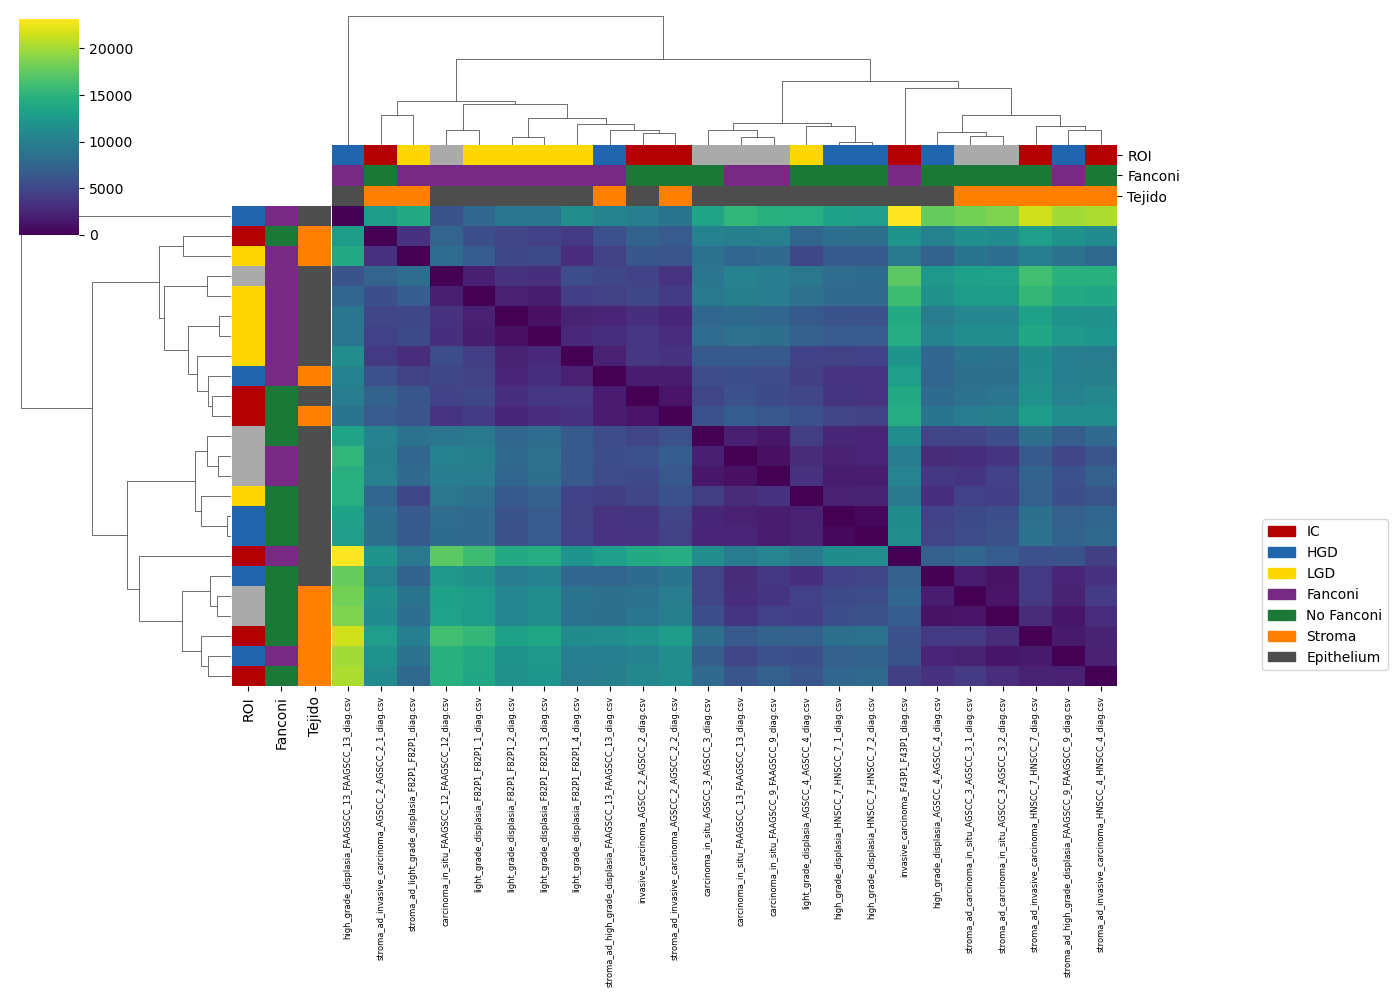

Procesando: wasserstein_dim1.csv


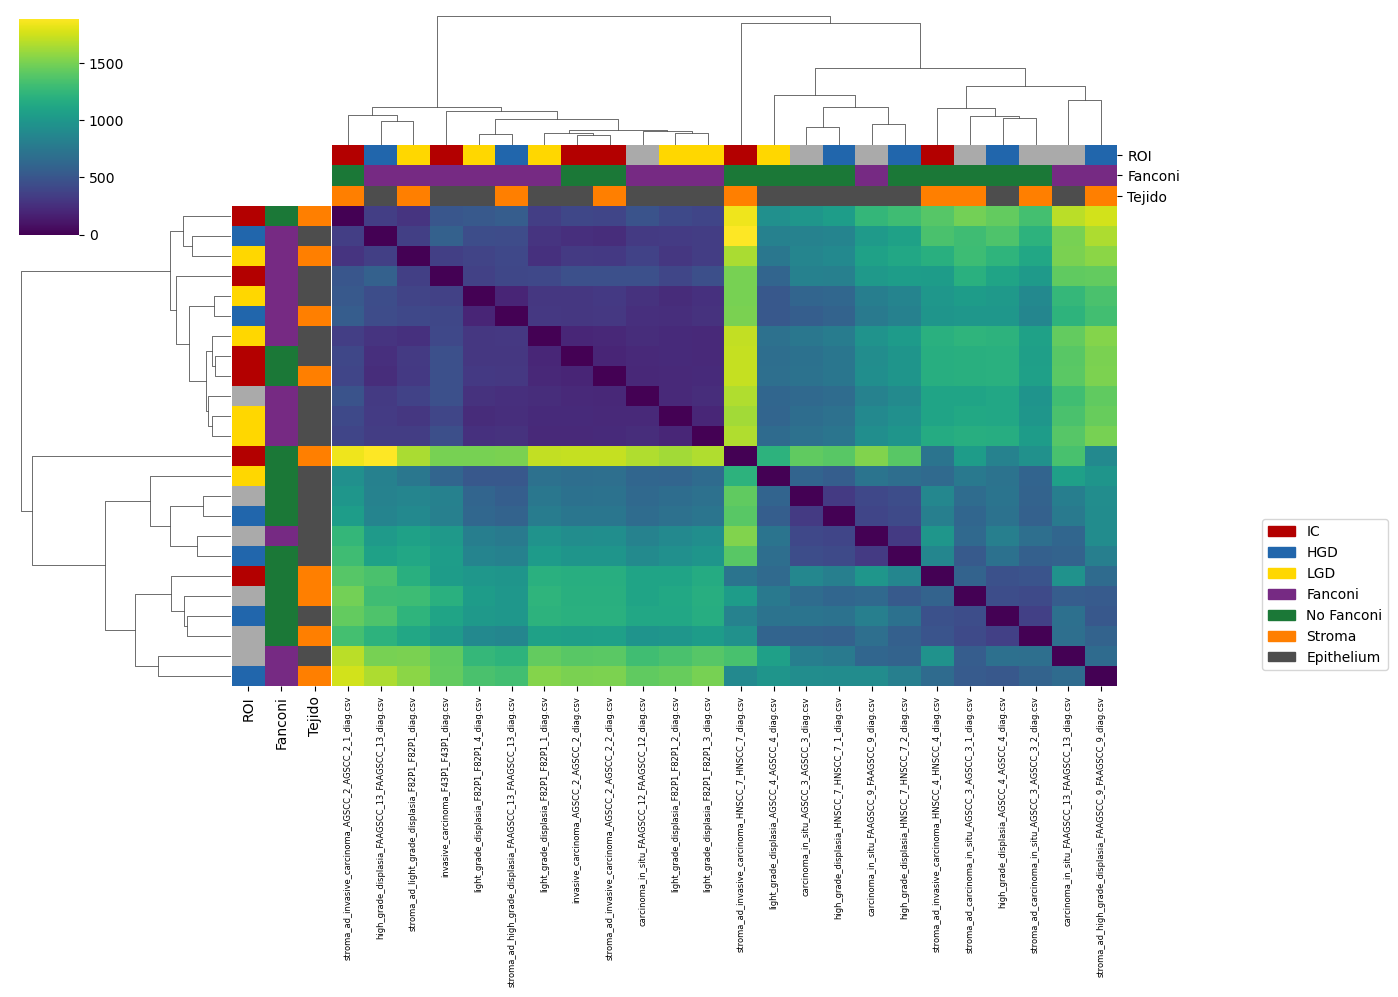

In [26]:
# Cambiar a ruta a donde distancias
ruta = "/home/jupyter-luisraul/resultados/distancias"

archivos = [
    f for f in os.listdir(ruta)
    if f.endswith(".csv")
]

for archivo in archivos:

    print("Procesando:", archivo)

    df = pd.read_csv(
        os.path.join(ruta, archivo),
        index_col=0
    )

    muestras = df.index.tolist()

    colores = pd.DataFrame({
        "ROI": [roi_colors[roi(x)] for x in muestras],
        "Fanconi": [fanconi_colors[fanconi(x)] for x in muestras],
        "Tejido": [tejido_colors[tejido(x)] for x in muestras]
    }, index=muestras)

    g = sns.clustermap(
        df,
        cmap="viridis",
        method="average",
        row_colors=colores,
        col_colors=colores,
        figsize=(12,12),
        yticklabels=False
    )

    plt.setp(
        g.ax_heatmap.get_xticklabels(),
        rotation=90,
        fontsize=6
    )

    g.fig.legend(
        handles=[
            Patch(color="#b30000", label="IC"),
            Patch(color="#2166ac", label="HGD"),
            Patch(color="#ffd700", label="LGD"),
            Patch(color="#762a83", label="Fanconi"),
            Patch(color="#1b7837", label="No Fanconi"),
            Patch(color="#ff7f00", label="Stroma"),
            Patch(color="#4d4d4d", label="Epithelium")
        ],
        bbox_to_anchor=(1.05, 0.5),
        loc="center left"
    )

    nombre = os.path.splitext(archivo)[0]

    plt.savefig(
        os.path.join(
            salida,
            f"clustermap_{nombre}.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()